<a href="https://colab.research.google.com/github/samslotin1/Hackathon_1/blob/main/Hackathon_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("movie_users_1000.csv")

# One specific user, not every Stephanie
stephanie = df[
    (df["name"] == "Stephanie") &
    (df["age"] == 24)
]

# One row per movie
all_movies = df[["movie", "genre"]].drop_duplicates()

def recommend_by_genre_taste(user_ratings_df, all_movies_df):

    genre_avg = (
        user_ratings_df
        .groupby("genre")["rating"]
        .mean()
        .reset_index()
        .rename(columns={"rating": "score"})
    )

    seen = user_ratings_df["movie"].tolist()

    unseen = all_movies_df[
        ~all_movies_df["movie"].isin(seen)
    ].copy()

    recs = (
        unseen
        .merge(genre_avg, on="genre", how="left")
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    return recs

recommendations = recommend_by_genre_taste(
    stephanie,
    all_movies
)

print(recommendations)

                 movie      genre  score
0         Pulp Fiction      crime    5.0
1           The Matrix     sci-fi    4.0
2            Toy Story  animation    2.0
3         Finding Nemo  animation    2.0
4         Forrest Gump      drama    NaN
5   Mad Max: Fury Road     action    NaN
6            Gladiator     action    NaN
7                Alien     horror    NaN
8              Get Out     horror    NaN
9      The Dark Knight     action    NaN
10               Se7en   thriller    NaN
11           John Wick     action    NaN
12            Parasite      drama    NaN


In [ ]:
recommendations = recommendations.dropna()

print(recommendations)

          movie      genre  score
0  Pulp Fiction      crime    5.0
1    The Matrix     sci-fi    4.0
2     Toy Story  animation    2.0
3  Finding Nemo  animation    2.0


In [ ]:
df[df["name"] == "Karen"][["name", "age"]].drop_duplicates()

,name,age
551,Karen,18
3645,Karen,19


In [ ]:
karen = df[
    (df["name"] == "Karen") &
    (df["age"] == 18)
]

print(karen[["name", "age", "movie", "rating"]])

      name  age      movie  rating
551  Karen   18    Titanic       2
552  Karen   18   Parasite       1
553  Karen   18  John Wick       3
554  Karen   18      Alien       1
555  Karen   18      Se7en       1


In [ ]:
common_ratings = stephanie.merge(
    karen,
    on="movie"
)

print(common_ratings.columns)

Index(['name_x', 'age_x', 'preferences_x', 'movie', 'genre_x', 'director_x',
       'rating_x', 'name_y', 'age_y', 'preferences_y', 'genre_y', 'director_y',
       'rating_y'],
      dtype='object')


In [ ]:
common_ratings.loc[:, ['movie', 'rating_x', 'rating_y']]

,movie,rating_x,rating_y
0,Titanic,5,2


In [ ]:
df[df["movie"].isin(stephanie["movie"])]

,name,age,preferences,movie,genre,director,rating
0,Stephanie,24,"animation, sci-fi",Shrek,animation,Andrew Adamson,2
1,Stephanie,24,"animation, sci-fi",Titanic,romance,James Cameron,5
2,Stephanie,24,"animation, sci-fi",Superbad,comedy,Greg Mottola,5
3,Stephanie,24,"animation, sci-fi",Joker,crime,Todd Phillips,5
4,Stephanie,24,"animation, sci-fi",Joker,crime,Todd Phillips,5
...,...,...,...,...,...,...,...
5520,Rhonda,50,"thriller, animation",Joker,crime,Todd Phillips,4
5521,Rhonda,50,"thriller, animation",Interstellar,sci-fi,Christopher Nolan,4
5522,Rhonda,50,"thriller, animation",Inception,sci-fi,Christopher Nolan,4
5525,Matthew,27,"sci-fi, horror",Superbad,comedy,Greg Mottola,3


In [ ]:
same_movies = df[df["movie"].isin(stephanie["movie"])]
same_movies.groupby(["name", "age"]).size()


name     age
Aaron    50     3
         61     2
         62     4
Albert   20     1
Alex     40     1
               ..
Xavier   61     1
Zachary  29     3
         34     3
         51     2
         53     1
Length: 848, dtype: int64

In [ ]:
same_movies.groupby(["name", "age"]).size().sort_values(ascending=False)

name       age
Kimberly   31     9
Kyle       29     8
Kimberly   60     8
Stephanie  24     8
James      34     7
                 ..
Mark       49     1
           45     1
           18     1
Zachary    53     1
Xavier     61     1
Length: 848, dtype: int64

In [ ]:
Kimberly = df[
    (df["name"] == "Kimberly") &
    (df["age"] == 31)
]
print(Kimberly[["name", "age", "movie", "rating"]])

         name  age               movie  rating
208  Kimberly   31           Inception       5
209  Kimberly   31           Inception       3
210  Kimberly   31           Inception       2
211  Kimberly   31        Forrest Gump       1
212  Kimberly   31           John Wick       5
213  Kimberly   31     The Dark Knight       2
214  Kimberly   31            Superbad       1
215  Kimberly   31  Mad Max: Fury Road       2
556  Kimberly   31          The Matrix       3
557  Kimberly   31        The Notebook       2
558  Kimberly   31               Shrek       5
559  Kimberly   31        Pulp Fiction       3
560  Kimberly   31            Superbad       1
561  Kimberly   31               Shrek       4
562  Kimberly   31               Shrek       1


In [ ]:
common_ratings = stephanie.merge(
    Kimberly,
    on="movie"
)
print(common_ratings.columns)

Index(['name_x', 'age_x', 'preferences_x', 'movie', 'genre_x', 'director_x',
       'rating_x', 'name_y', 'age_y', 'preferences_y', 'genre_y', 'director_y',
       'rating_y'],
      dtype='object')


In [ ]:
common_ratings[["movie", "rating_x", "rating_y"]]

,movie,rating_x,rating_y
0,Shrek,2,5
1,Shrek,2,4
2,Shrek,2,1
3,Superbad,5,1
4,Superbad,5,1
5,The Notebook,1,2
6,Inception,4,5
7,Inception,4,3
8,Inception,4,2


The generated dataset contains some duplicate movie ratings for users. Future improvements would include enforcing one rating per user per movie.

In [ ]:
from scipy.stats import pearsonr
x = common_ratings["rating_x"]
y = common_ratings["rating_y"]

corr, p_value = pearsonr(x, y)

print(corr)
print(p_value)

-0.27138141262110327
0.4799621643400049


In [ ]:
from scipy.cluster.vq import kmeans, vq

In [ ]:
user_movie_matrix = pd.pivot_table(
    df,
    index=["name", "age"],
    columns="movie",
    values="rating",
    aggfunc="mean",
    fill_value=0
)

user_movie_matrix.head()

movie      Alien  Finding Nemo  Forrest Gump  Get Out  Gladiator  Inception  \
name  age                                                                     
Aaron 50     4.0           2.0           5.0      0.0        0.0        0.0   
      61     0.0           0.0           3.0      0.0        0.0        0.0   
      62     0.0           0.0           2.0      0.0        0.0        2.0   
Adam  46     0.0           0.0           1.0      0.0        0.0        0.0   
Aimee 35     0.0           0.0           0.0      0.0        0.0        0.0   

movie      Interstellar  John Wick  Joker  Mad Max: Fury Road  Parasite  \
name  age                                                                 
Aaron 50            0.0        0.0    1.5                 0.0       0.0   
      61            1.0        0.0    0.0                 0.0       0.0   
      62            0.0        0.0    0.0                 0.0       0.0   
Adam  46            0.0        3.5    0.0                 2.0       0.0   
Aimee 35            0.0        0.0    0.0                 0.0       0.0   

movie      Pulp Fiction  Se7en  Shrek  Superbad  The Dark Knight  The Matrix  \
name  age                                                                      
Aaron 50            0.0    4.0    4.0       0.0              0.0         0.0   
      61            0.0    0.0    0.0       0.0              0.0         1.0   
      62            0.0    5.0    3.0       5.0              0.0         0.0   
Adam  46            0.0    1.0    0.0       0.0              0.0         5.0   
Aimee 35            1.0    1.0    0.0       0.0              0.0         0.0   

movie      The Notebook  Titanic  Toy Story  
name  age                                    
Aaron 50            0.0      0.0        0.0  
      61            2.0      0.0        0.0  
      62            2.0      0.0        0.0  
Adam  46            0.0      0.0        0.0  
Aimee 35            0.0      0.0        3.0

In [ ]:
centroids, distortion = kmeans(user_movie_matrix.values, 3)

clusters, distances = vq(user_movie_matrix.values, centroids)

user_movie_matrix["cluster"] = clusters

user_movie_matrix.head()

movie      Alien  Finding Nemo  Forrest Gump  Get Out  Gladiator  Inception  \
name  age                                                                     
Aaron 50     4.0           2.0           5.0      0.0        0.0        0.0   
      61     0.0           0.0           3.0      0.0        0.0        0.0   
      62     0.0           0.0           2.0      0.0        0.0        2.0   
Adam  46     0.0           0.0           1.0      0.0        0.0        0.0   
Aimee 35     0.0           0.0           0.0      0.0        0.0        0.0   

movie      Interstellar  John Wick  Joker  Mad Max: Fury Road  ...  \
name  age                                                      ...   
Aaron 50            0.0        0.0    1.5                 0.0  ...   
      61            1.0        0.0    0.0                 0.0  ...   
      62            0.0        0.0    0.0                 0.0  ...   
Adam  46            0.0        3.5    0.0                 2.0  ...   
Aimee 35            0.0        0.0    0.0                 0.0  ...   

movie      Pulp Fiction  Se7en  Shrek  Superbad  The Dark Knight  The Matrix  \
name  age                                                                      
Aaron 50            0.0    4.0    4.0       0.0              0.0         0.0   
      61            0.0    0.0    0.0       0.0              0.0         1.0   
      62            0.0    5.0    3.0       5.0              0.0         0.0   
Adam  46            0.0    1.0    0.0       0.0              0.0         5.0   
Aimee 35            1.0    1.0    0.0       0.0              0.0         0.0   

movie      The Notebook  Titanic  Toy Story  cluster  
name  age                                             
Aaron 50            0.0      0.0        0.0        1  
      61            2.0      0.0        0.0        1  
      62            2.0      0.0        0.0        1  
Adam  46            0.0      0.0        0.0        1  
Aimee 35            0.0      0.0        3.0        2  

[5 rows x 21 columns]

In [ ]:
user_movie_matrix["cluster"].value_counts()

,count
cluster,
1,620
0,169
2,167


Users were grouped into 3 clusters based on their movie ratings. Most users fell into Cluster 1, while Clusters 0 and 2 contained smaller groups of users with different rating patterns.

<Axes: ylabel='count'>

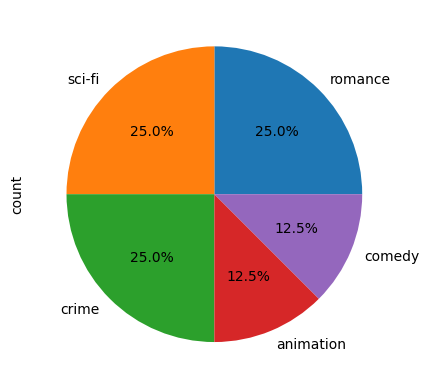

In [ ]:
stephanie["genre"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: xlabel='genre'>

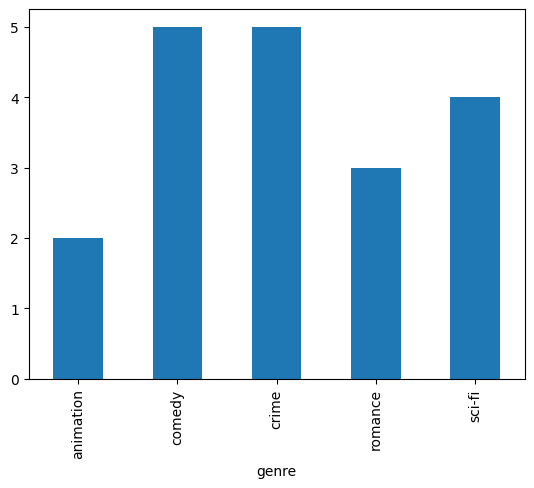

In [ ]:
stephanie.groupby("genre")["rating"].mean().plot.bar()

# Conclusion

For this project, I built a movie recommendation system using Python, Pandas, NumPy, and SciPy. The system recommends movies by looking at a user's watch history, preferred genres, and previous ratings.

The recommendation engine successfully identified unseen movies that matched a user's tastes. For example, movies were ranked based on genres that the user had rated highly in the past. This allowed the system to generate personalized recommendations rather than suggesting random movies.

I also used Pearson correlation to compare the ratings of different users. When comparing Stephanie (24) and Kimberly (31), the correlation coefficient was -0.27 with a p-value of 0.48. This indicates a weak negative relationship between their movie preferences, meaning they did not appear to have very similar tastes. While this specific comparison did not show a strong match, it demonstrated how Pearson correlation can be used to identify users with similar or different viewing preferences.

K-means clustering was then applied to group users based on their movie ratings. The algorithm divided users into three clusters, allowing users with similar rating patterns to be grouped together. Most users were assigned to Cluster 1, while smaller groups were assigned to Clusters 0 and 2.

Finally, visualizations were created to better understand user behavior. A pie chart showed the distribution of genres watched by Stephanie, while a bar chart displayed her average rating by genre. These visualizations helped highlight the genres she watched most often and the genres she enjoyed the most.

Overall, this project demonstrated how recommendation systems can combine user preferences, ratings, correlation analysis, clustering, and visualization techniques to generate personalized movie recommendations.
